<a href="https://colab.research.google.com/github/VictorDanielPedrozoJerez/Python/blob/main/PrimerLaboratorioAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Primer Trabajo Práctico - Análisis Numérico**
## Aproximación de Soluciones de Ecuaciones No Lineales
## Victor Daniel Pedrozo Jerez - 2202501



---
# **Introducción**



En el siguiente trabajo se estudiarán los métodos numéricos de bisección, secante, falsa posición, falsa posición modificada (Illinois) y Newton-Raphson. Para ello, se abordará el problema de encontrar la raíz cuadrada de un número real positivo $a$, es decir, dado $a > 0$, encontrar un número $x > 0$ tal que $x^2 = a$. Este problema se reformula como encontrar la raíz de la función $f(x) = x^2 - a$.

En este trabajo se presentará la implementación de cada uno de los métodos en Python, se analizará el comportamiento numérico de cada técnica, considerando aspectos como la convergencia, el orden y la velocidad de convergencia, así como los criterios de parada utilizados. Finalmente, se compararán los resultados obtenidos con el fin de obtener algunas conclusiones.





---


# **Marco teórico**



# Método de Bisección

El método de Bisección es una técnica robusta para encontrar raíces de funciones continuas en un intervalo $[a, b]$ donde $f(a) \cdot f(b) < 0$. Se basa en el Teorema del Valor Intermedio y consiste en dividir el intervalo a la mitad en cada iteración para acercarse progresivamente a la raíz. Es un método consistente siempre que se cumplan las condiciones iniciales y garantiza la convergencia aunque de manera lenta. Su orden de convergencia es lineal $(\alpha=1)$, lo que lo hace confiable pero no muy eficiente en comparación con otros métodos.

### Proceso:
1. Seleccionar el intervalo $[a, b]$ tal que $f(a) \cdot f(b) < 0$.

2. Calcular el punto medio $c = \frac{a + b}{2}$.
3. Evaluar $f(c)$:
- Si $f(c) = 0$, $c$ es la raíz.
- Si $f(a) \cdot f(c) < 0$, entonces $b = c$.
- Si $f(c) \cdot f(b) < 0$, entonces $a = c$.
4. Repetir hasta que $|b - a| < \epsilon$.







# Método de Falsa Posición




El método de Falsa Posición mejora el método de Bisección usando interpolación lineal para aproximar la raíz. Dado un intervalo $[a, b]$ con $f(a) \cdot f(b) < 0$, se calcula el punto de intersección de la recta entre $(a, f(a))$ y $(b, f(b))$ con el eje $x$. Es un método **consistente** y típicamente más rápido que Bisección. Sin embargo, puede estancarse si una de las evaluaciones de $f(x)$ no cambia significativamente. Su convergencia es generalmente lineal $(\alpha = 1)$ en el peor caso.

### Proceso:
1. Elegir $[a, b]$ tal que $f(a) \cdot f(b) < 0$.
2. Calcular:

   $
   c = b - \frac{f(b)(a - b)}{f(a) - f(b)}
   $
3. Evaluar $f(c)$:
- Si $f(c) = 0$, $c$ es la raíz.
- Si $f(a) \cdot f(c) < 0$, entonces $b = c$.
- Si $f(c) \cdot f(b) < 0$, entonces $a = c$.
4. Repetir hasta que $|f(c)| < \epsilon$.



# Método de falsa posición modificada (Illinois)

El método de Illinois es una variante del método de Falsa Posición diseñada para superar el problema del estancamiento. Al igual que en Falsa Posición, se usa interpolación lineal, pero si un extremo del intervalo permanece sin cambiar en dos iteraciones, se reduce el valor de la función en ese punto a la mitad. Esto asegura una mejor progresión hacia la raíz. Es un método consistente y con mejor convergencia que la Falsa Posición. Su orden de convergencia es de $\alpha \approx 1.442$ , lo que representa una mejora notable.

### Proceso:
1. Inicializar $[a, b]$ tal que $f(a) \cdot f(b) < 0$.
2. Calcular:
   $
   c = b - \frac{f(b)(a - b)}{f(a) - f(b)}
   $
3. Evaluar $f(c)$:
- Si $f(c) = 0$, $c$ es la raíz.
- Si $f(a) \cdot f(c) < 0$, entonces:
     - $b = c$
     - Si el signo de $f(a)$ no ha cambiado por segunda vez, multiplicar $f(a)$ por $1/2$.
- Si $f(b) \cdot f(c) < 0$, entonces:
     - $a = c$
     - Si el signo de $f(b)$ no ha cambiado por segunda vez, multiplicar $f(b)$ por $1/2$.
4. Repetir hasta que $|f(c)| < \epsilon$.






# Método de la Secante

El método de la **Secante** aproxima la raíz usando una recta secante entre dos puntos cercanos $x_0$ y $x_1$, sin necesidad de calcular derivadas. Es una mejora del método de Newton-Raphson para casos donde la derivada es difícil de obtener. Es **consistente** si la función es continua y suave, y su **convergencia** es más rápida que la de Bisección y Falsa Posición. Su **orden de convergencia** es **superlineal ($p \approx 1.618$)**, conocido como la razón áurea.

### Proceso:
1. Elegir dos puntos iniciales $x_0$ y $x_1$.
2. Calcular:

  $
   x_{n+1} = x_n - f(x_n) \cdot \frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}
   $
3. Repetir hasta que $|x_{n+1} - x_n| < \epsilon$.







# Método de Newton-Raphson

El método de Newton-Raphson es uno de los métodos más eficientes para encontrar raíces, siempre que la función sea derivable y la derivada no sea cero cerca de la raíz. Usa la tangente a la curva en un punto para aproximar la raíz. Es **consistente**, y si se inicia suficientemente cerca de la raíz, su **convergencia es cuadrática ($p = 2$)**, es decir, extremadamente rápida. Sin embargo, si se elige mal la aproximación inicial o si la derivada se anula, puede divergir.

### Proceso:
1. Elegir una aproximación inicial $x_0$.
2. Calcular:

   $
   x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
   $
3. Repetir hasta que $|x_{n+1} - x_n| < \epsilon$.



---
# Implementación de algoritmos
---


In [ ]:
# librerias usadas el los programas:

import math # usada para realizar opraciones
import time # usada para la medición de tiempo
from typing import Callable, Tuple, Dict, Union # usada para definir arreglos

# librerias usadas para graficas:
import pandas as pd
import matplotlib.pyplot as plt

# Funcon principal

In [ ]:
def raiz_cuadrada(a: float, aprox_inicial: Union[float, Tuple[float, float]],
                  metodo: str = 'newton', mostrar_tabla: bool = True,
                  mostrar_grafica: bool = True, **kwargs) -> Tuple[float, Dict, Dict]:
    """
    Calcula la raíz cuadrada de a usando el método especificado.

    Parameters:
    -----------
    a : float
        Número positivo del cual calcular la raíz cuadrada.
    aprox_inicial : float o tuple
        Aproximación inicial según el método.
    metodo : str
        Método a utilizar ('biseccion', 'secante', 'falsa_posicion',
                          'illinois', 'newton').
    mostrar_tabla : bool
        Si True, muestra la tabla de iteraciones.
    mostrar_grafica : bool
        Si True, muestra la gráfica de convergencia.
    kwargs : dict
        Parámetros adicionales para el método.

    Returns:
    --------
    resultado : float
        Aproximación de la raíz cuadrada.
    historico : dict
        Registro de la evolución del algoritmo.
    info : dict
        Información adicional sobre la ejecución.
    """
    if a < 0:
        raise ValueError("El número debe ser positivo para calcular su raíz cuadrada")

    # Definir la función f(x) = x^2 - a
    f = lambda x: x**2 - a

    # Seleccionar el método adecuado
    if metodo == 'biseccion':
        if isinstance(aprox_inicial, (int, float)):
            a0 = max(0, aprox_inicial / 2)
            b0 = aprox_inicial * 2 if aprox_inicial != 0 else 1
            param_iniciales = (a0, b0)
        else:
            param_iniciales = aprox_inicial
        resultado, historico, info, tabla = biseccion(f, param_iniciales, **kwargs)

    elif metodo == 'secante':
        if isinstance(aprox_inicial, (int, float)):
            x0 = aprox_inicial
            x1 = x0 * 1.1 if x0 != 0 else 0.1
            param_iniciales = (x0, x1)
        else:
            param_iniciales = aprox_inicial
        resultado, historico, info, tabla = secante(f, param_iniciales, **kwargs)

    elif metodo == 'falsa_posicion':
        if isinstance(aprox_inicial, (int, float)):
            a0 = max(0, aprox_inicial / 2)
            b0 = aprox_inicial * 2 if aprox_inicial != 0 else 1
            param_iniciales = (a0, b0)
        else:
            param_iniciales = aprox_inicial
        resultado, historico, info, tabla = falsa_posicion(f, param_iniciales, **kwargs)

    elif metodo == 'illinois':
        if isinstance(aprox_inicial, (int, float)):
            a0 = max(0, aprox_inicial / 2)
            b0 = aprox_inicial * 2 if aprox_inicial != 0 else 1
            param_iniciales = (a0, b0)
        else:
            param_iniciales = aprox_inicial
        resultado, historico, info, tabla = illinois(f, param_iniciales, **kwargs)

    elif metodo == 'newton':
        if isinstance(aprox_inicial, tuple):
            param_iniciales = aprox_inicial[0]
        else:
            param_iniciales = aprox_inicial

        # Definir la derivada f'(x) = 2x
        df = lambda x: 2 * x
        resultado, historico, info, tabla = newton_raphson(f, param_iniciales, df=df, **kwargs)

    else:
        raise ValueError(f"Método desconocido: {metodo}. Los métodos disponibles son: " +
                        "'biseccion', 'secante', 'falsa_posicion', 'illinois', 'newton'")

    # Mostrar tabla si se solicita
    if mostrar_tabla:
        print(f"\nTabla de iteraciones para método de {metodo.capitalize()}:")
        print(tabla.to_markdown(index=False, floatfmt=".6f"))

    # Mostrar gráfica si se solicita
    if mostrar_grafica:
        plt.figure(figsize=(10, 5))

        if metodo in ['biseccion', 'falsa_posicion', 'illinois']:
            plt.plot(tabla['Iteración'], tabla['|c_{n+1}-c_n|'], 'bo-', label='Error absoluto')
            plt.plot(tabla['Iteración'], tabla['|(c_{n+1}-c_n)/c_n|'], 'ro-', label='Error relativo')
        elif metodo == 'secante':
            plt.plot(tabla['Iteración'], tabla['|x_{n+2}-x_{n+1}|'], 'bo-', label='Error absoluto')
            plt.plot(tabla['Iteración'], tabla['|(x_{n+2}-x_{n+1})/x_{n+1}|'], 'ro-', label='Error relativo')
        else:  # newton
            plt.plot(tabla['Iteración'], tabla['|x_{n+1}-x_n|'], 'bo-', label='Error absoluto')
            plt.plot(tabla['Iteración'], tabla['|(x_{n+1}-x_n)/x_n|'], 'ro-', label='Error relativo')

        plt.title(f'Convergencia del método de {metodo.capitalize()}')
        plt.xlabel('Iteración')
        plt.ylabel('Error')
        plt.yscale('log')
        plt.grid(True)
        plt.legend()
        plt.show()

    return resultado, historico, info

# Método de bisección


In [ ]:
def biseccion(f: Callable, param_iniciales: Tuple[float, float],
              tolerancia: float = 1e-8, max_iter: int = 100, **kwargs) -> Tuple[float, Dict, Dict, pd.DataFrame]:
    a, b = param_iniciales
    fa, fb = f(a), f(b)

    if fa * fb >= 0:
        raise ValueError("La función debe cambiar de signo en el intervalo [a,b]")

    historico = {
        'iteraciones': [],
        'a': [],
        'b': [],
        'c': [],
        'fa': [],
        'fb': [],
        'fc': [],
        'error_abs': [],
        'error_rel': []
    }

    start_time = time.time()

    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)

        # Registrar datos
        historico['iteraciones'].append(i+1)
        historico['a'].append(a)
        historico['b'].append(b)
        historico['c'].append(c)
        historico['fa'].append(fa)
        historico['fb'].append(fb)
        historico['fc'].append(fc)

        # Calcular errores
        if i > 0:
            error_abs = abs(c - historico['c'][-2])
            error_rel = error_abs / historico['c'][-2]
            historico['error_abs'].append(error_abs)
            historico['error_rel'].append(error_rel)
            if error_abs < tolerancia or abs(fc) < tolerancia:
                break
        else:
            historico['error_abs'].append(float('nan'))
            historico['error_rel'].append(float('nan'))

        # Actualizar intervalo
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc

    # Crear tabla detallada
    tabla = pd.DataFrame({
        'Iteración': historico['iteraciones'],
        'a_n': historico['a'],
        'b_n': historico['b'],
        'c_n': historico['c'],
        'f(c_n)': historico['fc'],
        '|c_{n+1}-c_n|': historico['error_abs'],
        '|(c_{n+1}-c_n)/c_n|': historico['error_rel']
    })

    exec_time = time.time() - start_time

    info = {
        'iteraciones': i + 1,
        'tiempo': exec_time,
        'convergencia': 'lineal (p=1)',
        'error_final': abs(fc),
        'status': 'success' if abs(fc) < tolerancia else 'max_iter',
        'tabla': tabla
    }

    return c, historico, info, tabla

# Método de secante


In [ ]:
def secante(f: Callable, param_iniciales: Tuple[float, float],
            tolerancia: float = 1e-8, max_iter: int = 100, **kwargs) -> Tuple[float, Dict, Dict, pd.DataFrame]:
    x0, x1 = param_iniciales
    f0, f1 = f(x0), f(x1)

    historico = {
        'iteraciones': [],
        'x0': [],
        'x1': [],
        'x2': [],
        'f0': [],
        'f1': [],
        'error_abs': [],
        'error_rel': []
    }

    start_time = time.time()

    for i in range(max_iter):
        if abs(f1 - f0) < 1e-12:
            break

        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        f2 = f(x2)

        # Registrar datos
        historico['iteraciones'].append(i+1)
        historico['x0'].append(x0)
        historico['x1'].append(x1)
        historico['x2'].append(x2)
        historico['f0'].append(f0)
        historico['f1'].append(f1)

        # Calcular errores
        if i > 0:
            error_abs = abs(x2 - historico['x2'][-2])
            error_rel = error_abs / historico['x2'][-2]
            historico['error_abs'].append(error_abs)
            historico['error_rel'].append(error_rel)
            if error_abs < tolerancia or abs(f2) < tolerancia:
                break
        else:
            historico['error_abs'].append(float('nan'))
            historico['error_rel'].append(float('nan'))

        x0, x1 = x1, x2
        f0, f1 = f1, f2

    # Crear tabla detallada
    tabla = pd.DataFrame({
        'Iteración': historico['iteraciones'],
        'x_n': historico['x1'],
        'x_{n+1}': historico['x2'],
        'f(x_n)': historico['f1'],
        'f(x_{n+1})': [f(x) for x in historico['x2']],
        '|x_{n+2}-x_{n+1}|': historico['error_abs'],
        '|(x_{n+2}-x_{n+1})/x_{n+1}|': historico['error_rel']
    })

    exec_time = time.time() - start_time

    info = {
        'iteraciones': i + 1,
        'tiempo': exec_time,
        'convergencia': 'superlineal (p≈1.618)',
        'error_final': abs(f2),
        'status': 'success' if abs(f2) < tolerancia else 'max_iter',
        'tabla': tabla
    }

    return x2, historico, info, tabla

# Método de falsa posición

In [ ]:
def falsa_posicion(f: Callable, param_iniciales: Tuple[float, float],
                   tolerancia: float = 1e-8, max_iter: int = 100, **kwargs) -> Tuple[float, Dict, Dict, pd.DataFrame]:
    a, b = param_iniciales
    fa, fb = f(a), f(b)

    if fa * fb >= 0:
        raise ValueError("La función debe cambiar de signo en el intervalo [a,b]")

    historico = {
        'iteraciones': [],
        'a': [],
        'b': [],
        'c': [],
        'fa': [],
        'fb': [],
        'fc': [],
        'error_abs': [],
        'error_rel': []
    }

    start_time = time.time()

    for i in range(max_iter):
        c = (a * fb - b * fa) / (fb - fa)
        fc = f(c)

        # Registrar datos
        historico['iteraciones'].append(i+1)
        historico['a'].append(a)
        historico['b'].append(b)
        historico['c'].append(c)
        historico['fa'].append(fa)
        historico['fb'].append(fb)
        historico['fc'].append(fc)

        # Calcular errores
        if i > 0:
            error_abs = abs(c - historico['c'][-2])
            error_rel = error_abs / historico['c'][-2]
            historico['error_abs'].append(error_abs)
            historico['error_rel'].append(error_rel)
            if error_abs < tolerancia or abs(fc) < tolerancia:
                break
        else:
            historico['error_abs'].append(float('nan'))
            historico['error_rel'].append(float('nan'))

        # Actualizar intervalo
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc

    # Crear tabla detallada
    tabla = pd.DataFrame({
        'Iteración': historico['iteraciones'],
        'a_n': historico['a'],
        'b_n': historico['b'],
        'c_n': historico['c'],
        'f(c_n)': historico['fc'],
        '|c_{n+1}-c_n|': historico['error_abs'],
        '|(c_{n+1}-c_n)/c_n|': historico['error_rel']
    })

    exec_time = time.time() - start_time

    info = {
        'iteraciones': i + 1,
        'tiempo': exec_time,
        'convergencia': 'lineal (p=1)',
        'error_final': abs(fc),
        'status': 'success' if abs(fc) < tolerancia else 'max_iter',
        'tabla': tabla
    }

    return c, historico, info, tabla

# Método de falsa posición modificado (Illinois)


In [ ]:
def illinois(f: Callable, param_iniciales: Tuple[float, float],
             tolerancia: float = 1e-8, max_iter: int = 100, **kwargs) -> Tuple[float, Dict, Dict, pd.DataFrame]:
    a, b = param_iniciales
    fa, fb = f(a), f(b)

    if fa * fb >= 0:
        raise ValueError("La función debe cambiar de signo en el intervalo [a,b]")

    historico = {
        'iteraciones': [],
        'a': [],
        'b': [],
        'c': [],
        'fa': [],
        'fb': [],
        'fc': [],
        'error_abs': [],
        'error_rel': []
    }

    start_time = time.time()

    for i in range(max_iter):
        c = (a * fb - b * fa) / (fb - fa)
        fc = f(c)

        # Registrar datos
        historico['iteraciones'].append(i+1)
        historico['a'].append(a)
        historico['b'].append(b)
        historico['c'].append(c)
        historico['fa'].append(fa)
        historico['fb'].append(fb)
        historico['fc'].append(fc)

        # Calcular errores
        if i > 0:
            error_abs = abs(c - historico['c'][-2])
            error_rel = error_abs / historico['c'][-2]
            historico['error_abs'].append(error_abs)
            historico['error_rel'].append(error_rel)
            if error_abs < tolerancia or abs(fc) < tolerancia:
                break
        else:
            historico['error_abs'].append(float('nan'))
            historico['error_rel'].append(float('nan'))

        # Actualizar intervalo con modificación Illinois
        if fa * fc < 0:
            b, fb = c, fc
            # Si a no cambia, dividir fa por 2
            if i > 0 and historico['a'][-2] == a:
                fa = fa / 2
        else:
            a, fa = c, fc
            # Si b no cambia, dividir fb por 2
            if i > 0 and historico['b'][-2] == b:
                fb = fb / 2

    # Crear tabla
    tabla = pd.DataFrame({
        'Iteración': historico['iteraciones'],
        'a_n': historico['a'],
        'b_n': historico['b'],
        'c_n': historico['c'],
        'f(c_n)': historico['fc'],
        '|c_{n+1}-c_n|': historico['error_abs'],
        '|(c_{n+1}-c_n)/c_n|': historico['error_rel']
    })

    exec_time = time.time() - start_time

    info = {
        'iteraciones': i + 1,
        'tiempo': exec_time,
        'convergencia': 'superlineal (p>1)',
        'error_final': abs(fc),
        'status': 'success' if abs(fc) < tolerancia else 'max_iter',
        'tabla': tabla
    }

    return c, historico, info, tabla

# Método de Newton-Raphson

In [ ]:
def newton_raphson(f: Callable, param_iniciales: float,
                   tolerancia: float = 1e-8, max_iter: int = 100,
                   df: Callable = None, **kwargs) -> Tuple[float, Dict, Dict, pd.DataFrame]:
    x = param_iniciales

    # Si no se proporciona la derivada, usar diferencia finita
    if df is None:
        h = kwargs.get('h', 1e-5)
        df = lambda x: (f(x + h) - f(x - h)) / (2 * h)

    historico = {
        'iteraciones': [],
        'x': [],
        'fx': [],
        'error_abs': [],
        'error_rel': []
    }

    start_time = time.time()

    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)

        if abs(dfx) < 1e-12:
            break

        x_new = x - fx / dfx
        fx_new = f(x_new)

        # Registrar datos
        historico['iteraciones'].append(i+1)
        historico['x'].append(x_new)
        historico['fx'].append(fx_new)

        # Calcular errores
        if i > 0:
            error_abs = abs(x_new - historico['x'][-2])
            error_rel = error_abs / historico['x'][-2]
            historico['error_abs'].append(error_abs)
            historico['error_rel'].append(error_rel)
            if error_abs < tolerancia or abs(fx_new) < tolerancia:
                break
        else:
            historico['error_abs'].append(float('nan'))
            historico['error_rel'].append(float('nan'))

        x = x_new

    # Crear tabla detallada
    tabla = pd.DataFrame({
        'Iteración': historico['iteraciones'],
        'x_n': historico['x'],
        'f(x_n)': historico['fx'],
        '|x_{n+1}-x_n|': historico['error_abs'],
        '|(x_{n+1}-x_n)/x_n|': historico['error_rel']
    })

    exec_time = time.time() - start_time

    info = {
        'iteraciones': i + 1,
        'tiempo': exec_time,
        'convergencia': 'cuadrática (p=2)',
        'error_final': abs(fx_new),
        'status': 'success' if abs(fx_new) < tolerancia else 'max_iter',
        'tabla': tabla
    }

    return x_new, historico, info, tabla



---

# Resultados

---




# Método de bisección
 Prueba para los casos conocidos: $\sqrt{4}$, $\sqrt{9}$, $\sqrt{16}$ (como diferentes intervalos), $\sqrt{25}$, $\sqrt{100}$






Tabla de iteraciones para método de Biseccion:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 1.000000 | 5.000000 | 3.000000 | -7.000000 |      nan        |            nan        |
|    2.000000 | 3.000000 | 5.000000 | 4.000000 |  0.000000 |        1.000000 |              0.333333 |


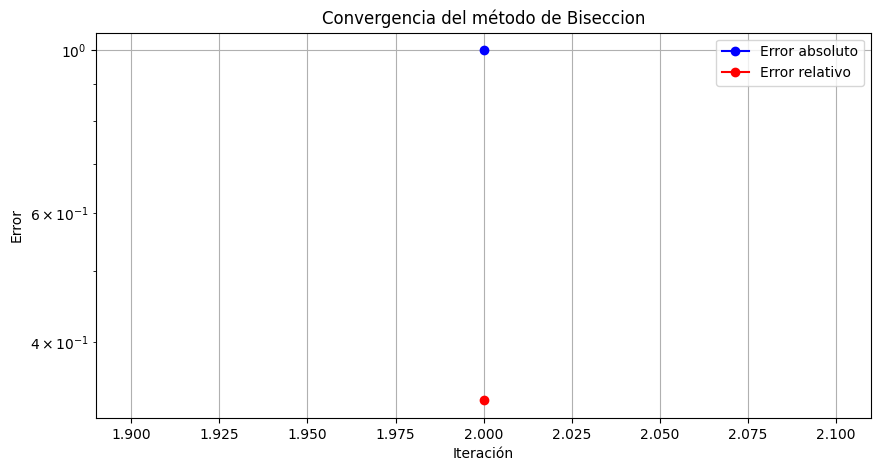


Tabla de iteraciones para método de Biseccion:
|   Iteración |      a_n |      b_n |      c_n |   f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|---------:|----------------:|----------------------:|
|    1.000000 | 3.000000 | 5.000000 | 4.000000 | 0.000000 |      nan        |            nan        |
|    2.000000 | 4.000000 | 5.000000 | 4.500000 | 4.250000 |        0.500000 |              0.125000 |
|    3.000000 | 4.500000 | 5.000000 | 4.750000 | 6.562500 |        0.250000 |              0.055556 |
|    4.000000 | 4.750000 | 5.000000 | 4.875000 | 7.765625 |        0.125000 |              0.026316 |
|    5.000000 | 4.875000 | 5.000000 | 4.937500 | 8.378906 |        0.062500 |              0.012821 |
|    6.000000 | 4.937500 | 5.000000 | 4.968750 | 8.688477 |        0.031250 |              0.006329 |
|    7.000000 | 4.968750 | 5.000000 | 4.984375 | 8.843994 |        0.015625 |              0.003145 |
|    8.000000 | 4.984375 | 5.00000

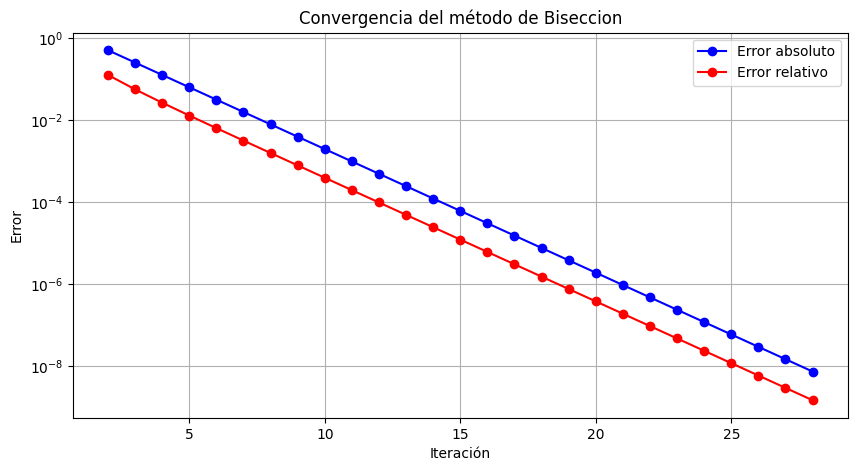


Tabla de iteraciones para método de Biseccion:
|   Iteración |      a_n |       b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|----------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 1.000000 | 10.000000 | 5.500000 | 14.250000 |      nan        |            nan        |
|    2.000000 | 1.000000 |  5.500000 | 3.250000 | -5.437500 |        2.250000 |              0.409091 |
|    3.000000 | 3.250000 |  5.500000 | 4.375000 |  3.140625 |        1.125000 |              0.346154 |
|    4.000000 | 3.250000 |  4.375000 | 3.812500 | -1.464844 |        0.562500 |              0.128571 |
|    5.000000 | 3.812500 |  4.375000 | 4.093750 |  0.758789 |        0.281250 |              0.073770 |
|    6.000000 | 3.812500 |  4.093750 | 3.953125 | -0.372803 |        0.140625 |              0.034351 |
|    7.000000 | 3.953125 |  4.093750 | 4.023438 |  0.188049 |        0.070312 |              0.017787 |
|    8.000000 | 

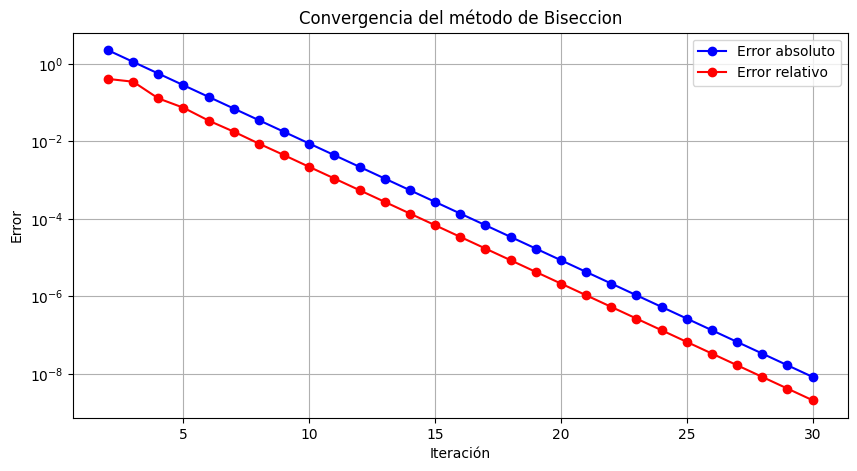

In [ ]:
# se calcula el mismo valos con diferentes intervalos para buscar colclusiones
resultado, historico, info = raiz_cuadrada(16, (1, 5), metodo='biseccion')
resultado, historico, info = raiz_cuadrada(16, (3, 5), metodo='biseccion')
resultado, historico, info = raiz_cuadrada(16, (1, 10), metodo='biseccion')

## Conclusiones
Se puede ver que el valor de convergencia depende claramente del intervalo inicial ya que se  puede pasar de encontrar la raíz en la iteración treinta a la iteración dos eligiendo un intervalo adecuado el problema es que para escoger dicho intervalo debemos tener más o menos clara cuál es la raíz por lo que no siempre ponemos elegir un intervalo con el que se converge rápidamente.


Tabla de iteraciones para método de Biseccion:
|   Iteración |      a_n |      b_n |      c_n |   f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|---------:|----------------:|----------------------:|
|    1.000000 | 1.000000 | 3.000000 | 2.000000 | 0.000000 |      nan        |            nan        |
|    2.000000 | 2.000000 | 3.000000 | 2.500000 | 2.250000 |        0.500000 |              0.250000 |
|    3.000000 | 2.500000 | 3.000000 | 2.750000 | 3.562500 |        0.250000 |              0.100000 |
|    4.000000 | 2.750000 | 3.000000 | 2.875000 | 4.265625 |        0.125000 |              0.045455 |
|    5.000000 | 2.875000 | 3.000000 | 2.937500 | 4.628906 |        0.062500 |              0.021739 |
|    6.000000 | 2.937500 | 3.000000 | 2.968750 | 4.813477 |        0.031250 |              0.010638 |
|    7.000000 | 2.968750 | 3.000000 | 2.984375 | 4.906494 |        0.015625 |              0.005263 |
|    8.000000 | 2.984375 | 3.00000

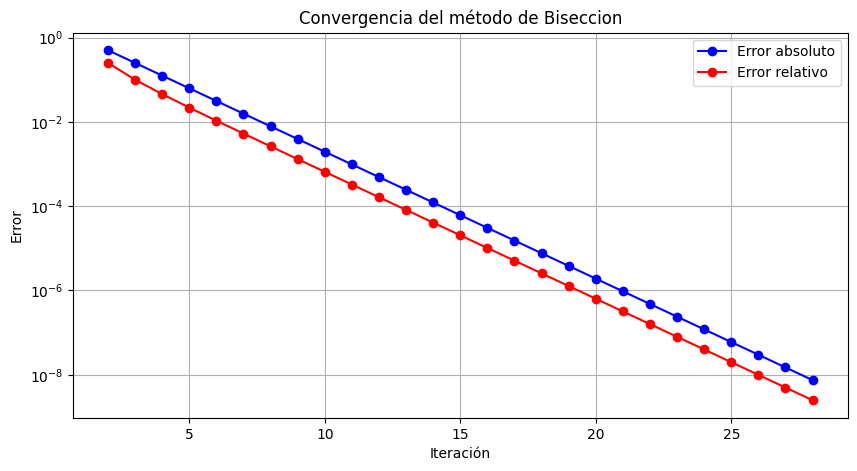


Tabla de iteraciones para método de Biseccion:
|   Iteración |      a_n |      b_n |      c_n |   f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|---------:|----------------:|----------------------:|
|    1.000000 | 2.000000 | 4.000000 | 3.000000 | 0.000000 |      nan        |            nan        |
|    2.000000 | 3.000000 | 4.000000 | 3.500000 | 3.250000 |        0.500000 |              0.166667 |
|    3.000000 | 3.500000 | 4.000000 | 3.750000 | 5.062500 |        0.250000 |              0.071429 |
|    4.000000 | 3.750000 | 4.000000 | 3.875000 | 6.015625 |        0.125000 |              0.033333 |
|    5.000000 | 3.875000 | 4.000000 | 3.937500 | 6.503906 |        0.062500 |              0.016129 |
|    6.000000 | 3.937500 | 4.000000 | 3.968750 | 6.750977 |        0.031250 |              0.007937 |
|    7.000000 | 3.968750 | 4.000000 | 3.984375 | 6.875244 |        0.015625 |              0.003937 |
|    8.000000 | 3.984375 | 4.00000

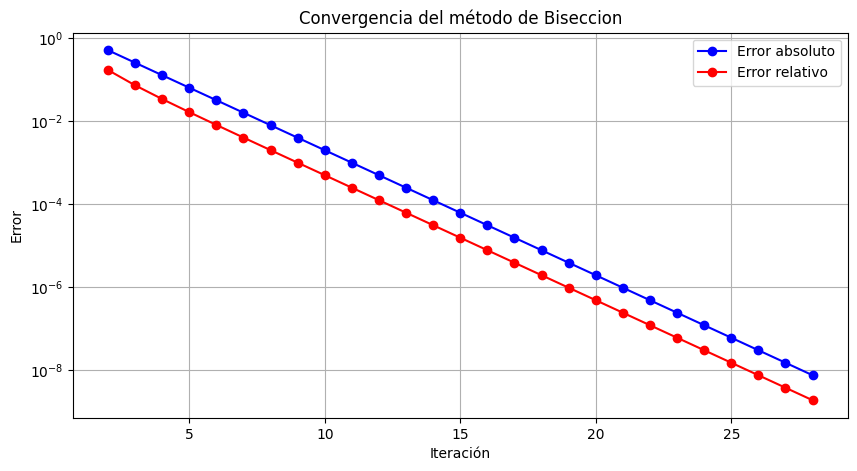


Tabla de iteraciones para método de Biseccion:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 4.000000 | 6.000000 | 5.000000 |  0.000000 |      nan        |            nan        |
|    2.000000 | 5.000000 | 6.000000 | 5.500000 |  5.250000 |        0.500000 |              0.100000 |
|    3.000000 | 5.500000 | 6.000000 | 5.750000 |  8.062500 |        0.250000 |              0.045455 |
|    4.000000 | 5.750000 | 6.000000 | 5.875000 |  9.515625 |        0.125000 |              0.021739 |
|    5.000000 | 5.875000 | 6.000000 | 5.937500 | 10.253906 |        0.062500 |              0.010638 |
|    6.000000 | 5.937500 | 6.000000 | 5.968750 | 10.625977 |        0.031250 |              0.005263 |
|    7.000000 | 5.968750 | 6.000000 | 5.984375 | 10.812744 |        0.015625 |              0.002618 |
|    8.000000 | 5.984375 

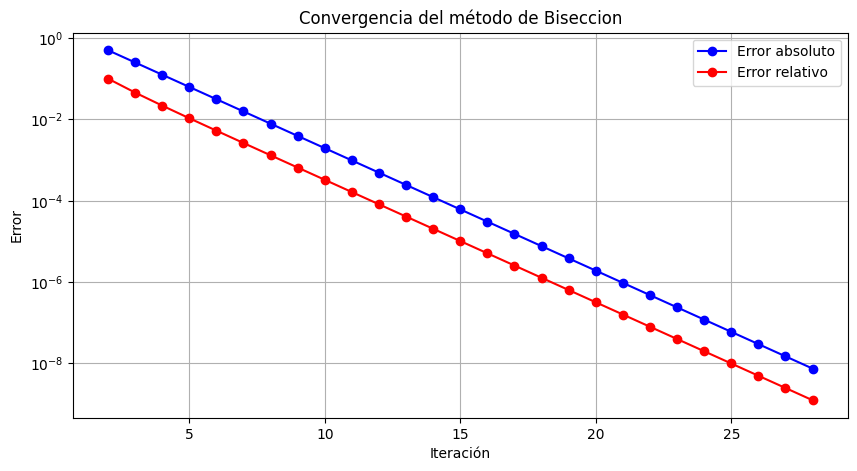


Tabla de iteraciones para método de Biseccion:
|   Iteración |       a_n |       b_n |       c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|----------:|----------:|----------:|----------:|----------------:|----------------------:|
|    1.000000 |  9.000000 | 11.000000 | 10.000000 |  0.000000 |      nan        |            nan        |
|    2.000000 | 10.000000 | 11.000000 | 10.500000 | 10.250000 |        0.500000 |              0.050000 |
|    3.000000 | 10.500000 | 11.000000 | 10.750000 | 15.562500 |        0.250000 |              0.023810 |
|    4.000000 | 10.750000 | 11.000000 | 10.875000 | 18.265625 |        0.125000 |              0.011628 |
|    5.000000 | 10.875000 | 11.000000 | 10.937500 | 19.628906 |        0.062500 |              0.005747 |
|    6.000000 | 10.937500 | 11.000000 | 10.968750 | 20.313477 |        0.031250 |              0.002857 |
|    7.000000 | 10.968750 | 11.000000 | 10.984375 | 20.656494 |        0.015625 |              0.001425 

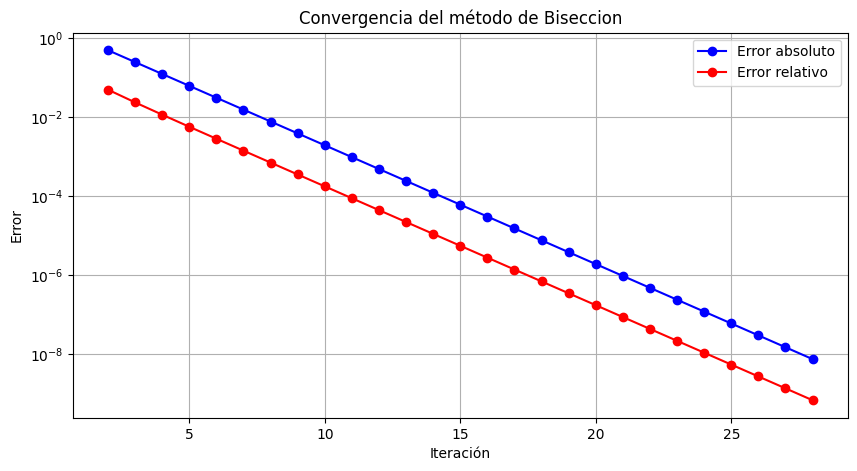

In [ ]:
resultado, historico, info = raiz_cuadrada(4, (1, 3), metodo='biseccion')
resultado, historico, info = raiz_cuadrada(9, (2, 4), metodo='biseccion')
resultado, historico, info = raiz_cuadrada(25, (4, 6), metodo='biseccion')
resultado, historico, info = raiz_cuadrada(100, (9, 11), metodo='biseccion')


## Conclusiones


Podemos ver como el error se reduce de manera constante y se puede ver como efectivamente el intervalo se reduce en un factor de dos.
  





# Método de secante
 Prueba para los casos conocidos: $\sqrt{4}$, $\sqrt{9}$, $\sqrt{16}$ (con diferentes valores iniciales), $\sqrt{25}$, $\sqrt{100}$


Tabla de iteraciones para método de Secante:
|   Iteración |      x_n |   x_{n+1} |    f(x_n) |   f(x_{n+1}) |   |x_{n+2}-x_{n+1}| |   |(x_{n+2}-x_{n+1})/x_{n+1}| |
|------------:|---------:|----------:|----------:|-------------:|--------------------:|------------------------------:|
|    1.000000 | 5.000000 |  3.500000 |  9.000000 |    -3.750000 |          nan        |                    nan        |
|    2.000000 | 3.500000 |  3.941176 | -3.750000 |    -0.467128 |            0.441176 |                      0.126050 |
|    3.000000 | 3.941176 |  4.003953 | -0.467128 |     0.031636 |            0.062776 |                      0.015928 |
|    4.000000 | 4.003953 |  3.999971 |  0.031636 |    -0.000234 |            0.003982 |                      0.000994 |
|    5.000000 | 3.999971 |  4.000000 | -0.000234 |    -0.000000 |            0.000029 |                      0.000007 |
|    6.000000 | 4.000000 |  4.000000 | -0.000000 |     0.000000 |            0.000000 |                      0.000

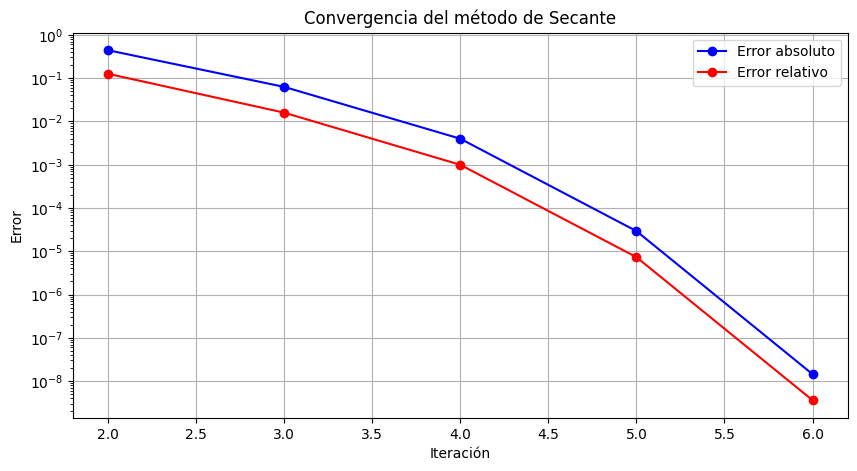


Tabla de iteraciones para método de Secante:
|   Iteración |      x_n |   x_{n+1} |    f(x_n) |   f(x_{n+1}) |   |x_{n+2}-x_{n+1}| |   |(x_{n+2}-x_{n+1})/x_{n+1}| |
|------------:|---------:|----------:|----------:|-------------:|--------------------:|------------------------------:|
|    1.000000 | 5.000000 |  3.875000 |  9.000000 |    -0.984375 |          nan        |                    nan        |
|    2.000000 | 3.875000 |  3.985915 | -0.984375 |    -0.112478 |            0.110915 |                      0.028623 |
|    3.000000 | 3.985915 |  4.000224 | -0.112478 |     0.001792 |            0.014308 |                      0.003590 |
|    4.000000 | 4.000224 |  4.000000 |  0.001792 |    -0.000003 |            0.000224 |                      0.000056 |
|    5.000000 | 4.000000 |  4.000000 | -0.000003 |    -0.000000 |            0.000000 |                      0.000000 |


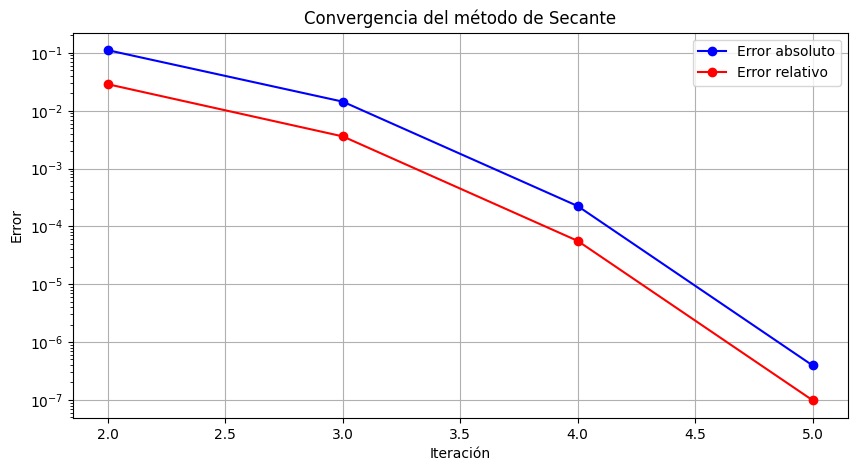


Tabla de iteraciones para método de Secante:
|   Iteración |       x_n |   x_{n+1} |     f(x_n) |   f(x_{n+1}) |   |x_{n+2}-x_{n+1}| |   |(x_{n+2}-x_{n+1})/x_{n+1}| |
|------------:|----------:|----------:|-----------:|-------------:|--------------------:|------------------------------:|
|    1.000000 |  1.000000 | 16.000000 | -15.000000 |   240.000000 |          nan        |                    nan        |
|    2.000000 | 16.000000 |  1.882353 | 240.000000 |   -12.456747 |           14.117647 |                      0.882353 |
|    3.000000 |  1.882353 |  2.578947 | -12.456747 |    -9.349030 |            0.696594 |                      0.370066 |
|    4.000000 |  2.578947 |  4.674532 |  -9.349030 |     5.851245 |            2.095584 |                      0.812573 |
|    5.000000 |  4.674532 |  3.867850 |   5.851245 |    -1.039734 |            0.806681 |                      0.172569 |
|    6.000000 |  3.867850 |  3.989565 |  -1.039734 |    -0.083371 |            0.121715 |           

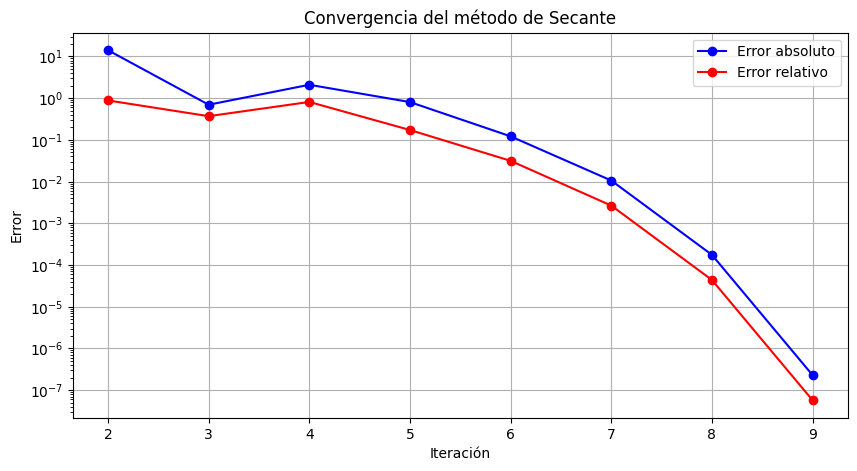

In [ ]:
resultado, historico, info = raiz_cuadrada(16, (1, 5), metodo='secante')
resultado, historico, info = raiz_cuadrada(16, (3, 5), metodo='secante')
resultado, historico, info = raiz_cuadrada(16, (0, 1), metodo='secante')

## Conclusiones
Gracias al último grafico podemos ver de forma más clara como los valores iniciales pueden alterar este método. Al elegir valores de $x_0$ y $x_1$ que se encuentren al mismo lado de la raíz como lo hicimos en el último caso donde $0, 1<\sqrt{16}$, logramos ver cómo hay algunos saltos en los resultados y en la gráfica del error se ve como este llega a aumentar su valor aunque la iteración avance aun así logra estabilizarse y finalmente converge.   


Tabla de iteraciones para método de Secante:
|   Iteración |      x_n |   x_{n+1} |    f(x_n) |   f(x_{n+1}) |   |x_{n+2}-x_{n+1}| |   |(x_{n+2}-x_{n+1})/x_{n+1}| |
|------------:|---------:|----------:|----------:|-------------:|--------------------:|------------------------------:|
|    1.000000 | 5.000000 |  2.375000 | 21.000000 |     1.640625 |          nan        |                    nan        |
|    2.000000 | 2.375000 |  2.152542 |  1.640625 |     0.633439 |            0.222458 |                      0.093666 |
|    3.000000 | 2.152542 |  2.012635 |  0.633439 |     0.050698 |            0.139908 |                      0.064997 |
|    4.000000 | 2.012635 |  2.000463 |  0.050698 |     0.001851 |            0.012172 |                      0.006048 |
|    5.000000 | 2.000463 |  2.000001 |  0.001851 |     0.000006 |            0.000461 |                      0.000231 |
|    6.000000 | 2.000001 |  2.000000 |  0.000006 |     0.000000 |            0.000001 |                      0.000

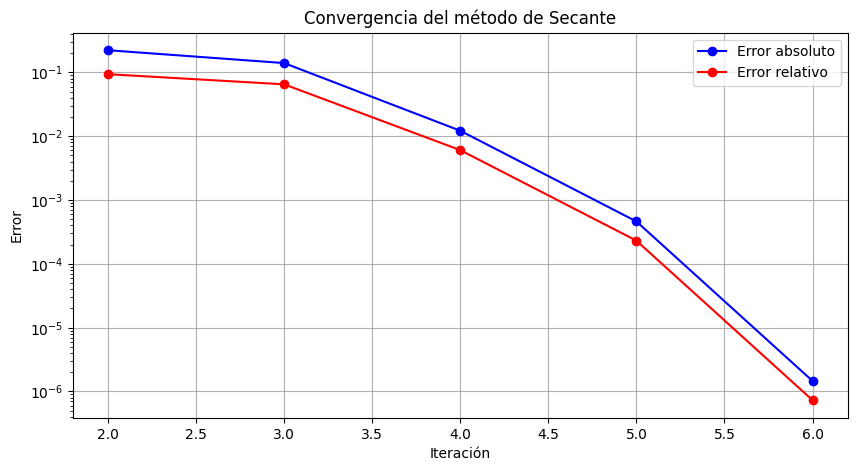


Tabla de iteraciones para método de Secante:
|   Iteración |      x_n |   x_{n+1} |    f(x_n) |   f(x_{n+1}) |   |x_{n+2}-x_{n+1}| |   |(x_{n+2}-x_{n+1})/x_{n+1}| |
|------------:|---------:|----------:|----------:|-------------:|--------------------:|------------------------------:|
|    1.000000 | 4.000000 |  2.833333 |  7.000000 |    -0.972222 |          nan        |                    nan        |
|    2.000000 | 2.833333 |  2.975610 | -0.972222 |    -0.145747 |            0.142276 |                      0.050215 |
|    3.000000 | 2.975610 |  3.000700 | -0.145747 |     0.004199 |            0.025090 |                      0.008432 |
|    4.000000 | 3.000700 |  2.999997 |  0.004199 |    -0.000017 |            0.000703 |                      0.000234 |
|    5.000000 | 2.999997 |  3.000000 | -0.000017 |    -0.000000 |            0.000003 |                      0.000001 |


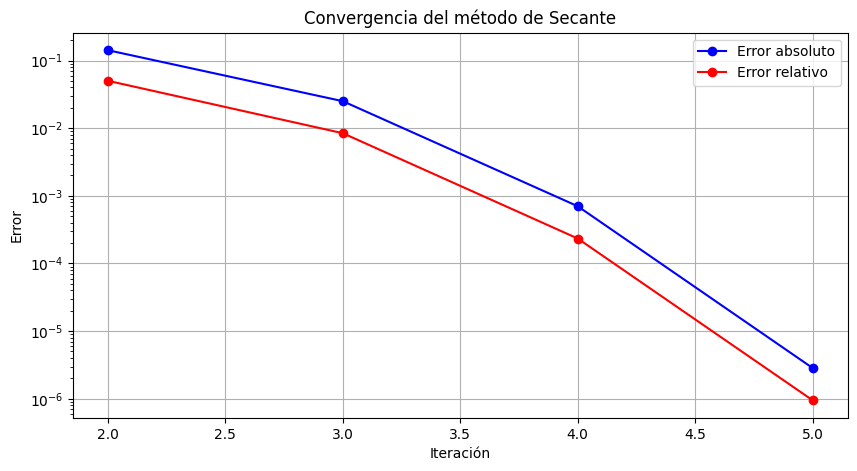


Tabla de iteraciones para método de Secante:
|   Iteración |      x_n |   x_{n+1} |    f(x_n) |   f(x_{n+1}) |   |x_{n+2}-x_{n+1}| |   |(x_{n+2}-x_{n+1})/x_{n+1}| |
|------------:|---------:|----------:|----------:|-------------:|--------------------:|------------------------------:|
|    1.000000 | 6.000000 |  4.900000 | 11.000000 |    -0.990000 |          nan        |                    nan        |
|    2.000000 | 4.900000 |  4.990826 | -0.990000 |    -0.091659 |            0.090826 |                      0.018536 |
|    3.000000 | 4.990826 |  5.000093 | -0.091659 |     0.000928 |            0.009267 |                      0.001857 |
|    4.000000 | 5.000093 |  5.000000 |  0.000928 |    -0.000001 |            0.000093 |                      0.000019 |
|    5.000000 | 5.000000 |  5.000000 | -0.000001 |    -0.000000 |            0.000000 |                      0.000000 |


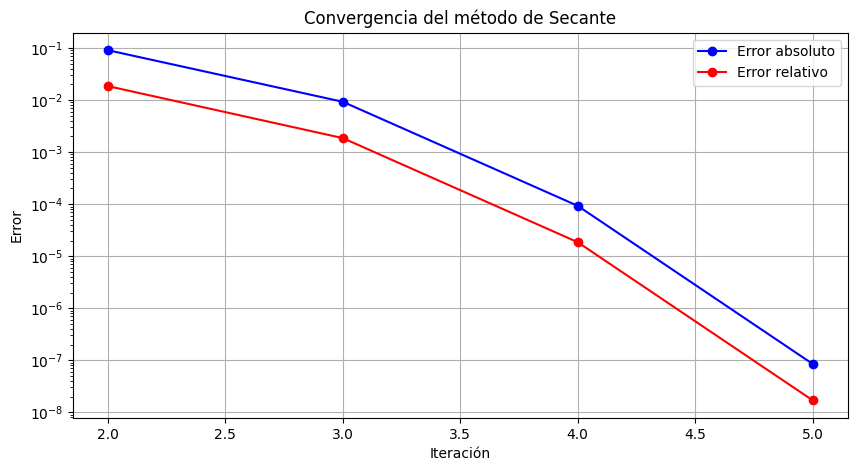


Tabla de iteraciones para método de Secante:
|   Iteración |       x_n |   x_{n+1} |    f(x_n) |   f(x_{n+1}) |   |x_{n+2}-x_{n+1}| |   |(x_{n+2}-x_{n+1})/x_{n+1}| |
|------------:|----------:|----------:|----------:|-------------:|--------------------:|------------------------------:|
|    1.000000 | 11.000000 |  9.950000 | 21.000000 |    -0.997500 |          nan        |                    nan        |
|    2.000000 |  9.950000 |  9.997613 | -0.997500 |    -0.047727 |            0.047613 |                      0.004785 |
|    3.000000 |  9.997613 | 10.000006 | -0.047727 |     0.000120 |            0.002393 |                      0.000239 |
|    4.000000 | 10.000006 | 10.000000 |  0.000120 |    -0.000000 |            0.000006 |                      0.000001 |
|    5.000000 | 10.000000 | 10.000000 | -0.000000 |     0.000000 |            0.000000 |                      0.000000 |


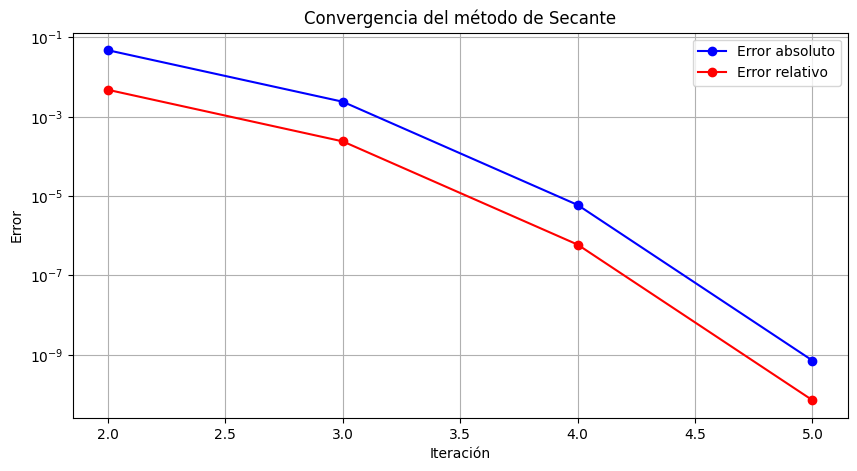

In [ ]:
resultado, historico, info = raiz_cuadrada(4, (3, 5), metodo='secante')
resultado, historico, info = raiz_cuadrada(9, (2, 4), metodo='secante')
resultado, historico, info = raiz_cuadrada(25, (4, 6), metodo='secante')
resultado, historico, info = raiz_cuadrada(100, (9, 11), metodo='secante')

## Conclusiones
El método de la secante ofrece una convergencia rápida (orden ~1.618) sin necesidad de calcular derivadas, siendo más eficiente que la bisección pero menos robusto ya que su éxito depende demasiado de la elección de los puntos iniciales: si están cerca de la raíz, converge rápidamente; si no, puede fallar. Es ideal cuando se busca velocidad y no se dispone de la derivada, pero requiere cuidado en su aplicación para garantizar resultados confiables.

# Método de falsa posición
 Prueba para los casos conocidos: $\sqrt{4}$, $\sqrt{9}$, $\sqrt{16}$ (como diferentes intervalos iniciales), $\sqrt{25}$, $\sqrt{100}$


Tabla de iteraciones para método de Falsa_posicion:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 3.000000 | 5.000000 | 3.875000 | -0.984375 |      nan        |            nan        |
|    2.000000 | 3.875000 | 5.000000 | 3.985915 | -0.112478 |        0.110915 |              0.028623 |
|    3.000000 | 3.985915 | 5.000000 | 3.998433 | -0.012537 |        0.012517 |              0.003140 |
|    4.000000 | 3.998433 | 5.000000 | 3.999826 | -0.001393 |        0.001393 |              0.000348 |
|    5.000000 | 3.999826 | 5.000000 | 3.999981 | -0.000155 |        0.000155 |              0.000039 |
|    6.000000 | 3.999981 | 5.000000 | 3.999998 | -0.000017 |        0.000017 |              0.000004 |
|    7.000000 | 3.999998 | 5.000000 | 4.000000 | -0.000002 |        0.000002 |              0.000000 |
|    8.000000 | 4.00

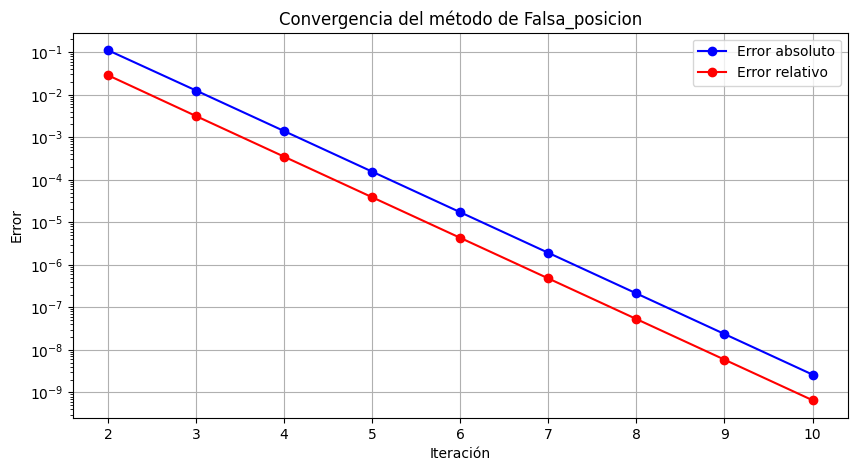


Tabla de iteraciones para método de Falsa_posicion:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 1.000000 | 5.000000 | 3.500000 | -3.750000 |      nan        |            nan        |
|    2.000000 | 3.500000 | 5.000000 | 3.941176 | -0.467128 |        0.441176 |              0.126050 |
|    3.000000 | 3.941176 | 5.000000 | 3.993421 | -0.052588 |        0.052245 |              0.013256 |
|    4.000000 | 3.993421 | 5.000000 | 3.999268 | -0.005852 |        0.005847 |              0.001464 |
|    5.000000 | 3.999268 | 5.000000 | 3.999919 | -0.000650 |        0.000650 |              0.000163 |
|    6.000000 | 3.999919 | 5.000000 | 3.999991 | -0.000072 |        0.000072 |              0.000018 |
|    7.000000 | 3.999991 | 5.000000 | 3.999999 | -0.000008 |        0.000008 |              0.000002 |
|    8.000000 | 3.99

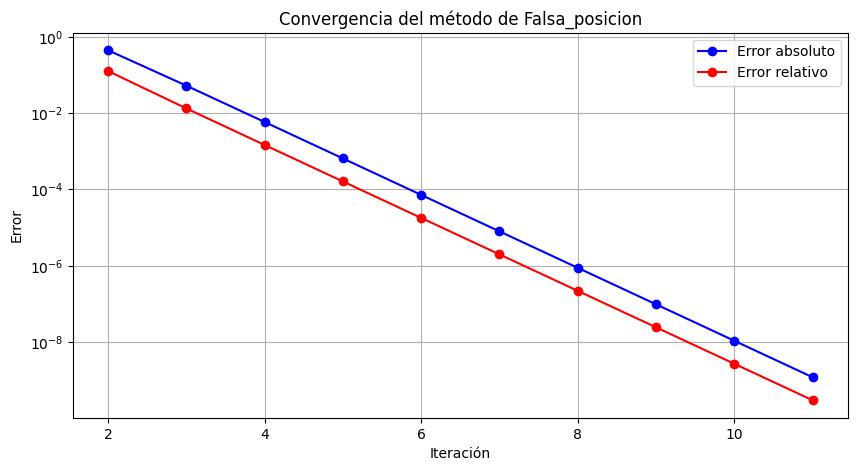


Tabla de iteraciones para método de Falsa_posicion:
|   Iteración |      a_n |       b_n |      c_n |     f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|----------:|---------:|-----------:|----------------:|----------------------:|
|    1.000000 | 0.000000 | 10.000000 | 1.600000 | -13.440000 |      nan        |            nan        |
|    2.000000 | 1.600000 | 10.000000 | 2.758621 |  -8.390012 |        1.158621 |              0.724138 |
|    3.000000 | 2.758621 | 10.000000 | 3.416216 |  -4.329467 |        0.657596 |              0.238378 |
|    4.000000 | 3.416216 | 10.000000 | 3.738920 |  -2.020476 |        0.322704 |              0.094462 |
|    5.000000 | 3.738920 | 10.000000 | 3.885982 |  -0.899141 |        0.147062 |              0.039333 |
|    6.000000 | 3.885982 | 10.000000 | 3.950734 |  -0.391700 |        0.064752 |              0.016663 |
|    7.000000 | 3.950734 | 10.000000 | 3.978811 |  -0.169059 |        0.028077 |              0.007107 |
| 

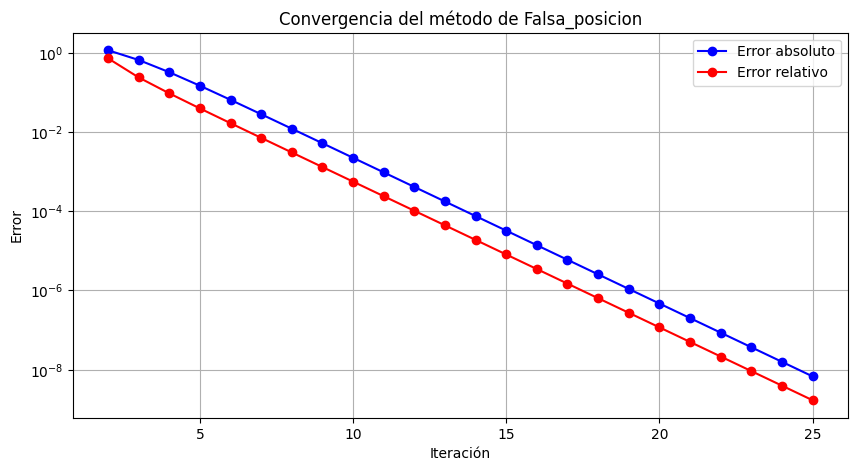

In [ ]:
resultado, historico, info = raiz_cuadrada(16, (3, 5), metodo='falsa_posicion')
resultado, historico, info = raiz_cuadrada(16, (1, 5), metodo='falsa_posicion')
resultado, historico, info = raiz_cuadrada(16, (0, 10), metodo='falsa_posicion')



Tabla de iteraciones para método de Falsa_posicion:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 1.000000 | 3.000000 | 1.750000 | -0.937500 |      nan        |            nan        |
|    2.000000 | 1.750000 | 3.000000 | 1.947368 | -0.207756 |        0.197368 |              0.112782 |
|    3.000000 | 1.947368 | 3.000000 | 1.989362 | -0.042440 |        0.041993 |              0.021564 |
|    4.000000 | 1.989362 | 3.000000 | 1.997868 | -0.008524 |        0.008506 |              0.004276 |
|    5.000000 | 1.997868 | 3.000000 | 1.999573 | -0.001706 |        0.001706 |              0.000854 |
|    6.000000 | 1.999573 | 3.000000 | 1.999915 | -0.000341 |        0.000341 |              0.000171 |
|    7.000000 | 1.999915 | 3.000000 | 1.999983 | -0.000068 |        0.000068 |              0.000034 |
|    8.000000 | 1.99

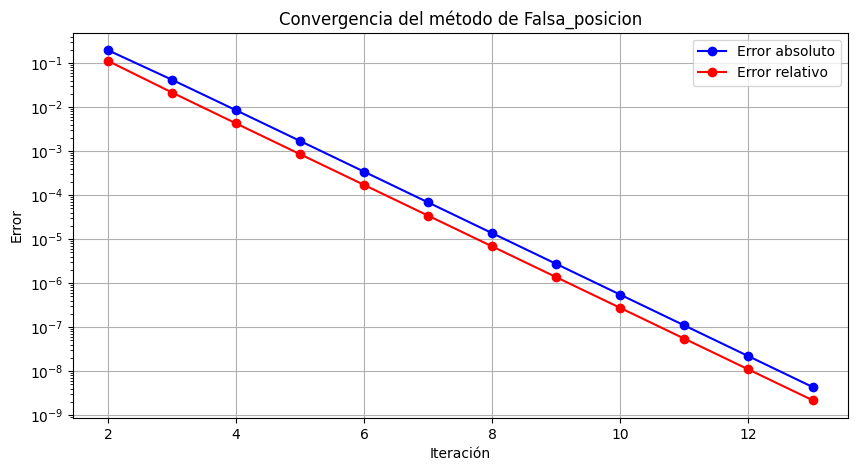


Tabla de iteraciones para método de Falsa_posicion:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 2.000000 | 4.000000 | 2.833333 | -0.972222 |      nan        |            nan        |
|    2.000000 | 2.833333 | 4.000000 | 2.975610 | -0.145747 |        0.142276 |              0.050215 |
|    3.000000 | 2.975610 | 4.000000 | 2.996503 | -0.020967 |        0.020894 |              0.007022 |
|    4.000000 | 2.996503 | 4.000000 | 2.999500 | -0.002998 |        0.002997 |              0.001000 |
|    5.000000 | 2.999500 | 4.000000 | 2.999929 | -0.000428 |        0.000428 |              0.000143 |
|    6.000000 | 2.999929 | 4.000000 | 2.999990 | -0.000061 |        0.000061 |              0.000020 |
|    7.000000 | 2.999990 | 4.000000 | 2.999999 | -0.000009 |        0.000009 |              0.000003 |
|    8.000000 | 2.99

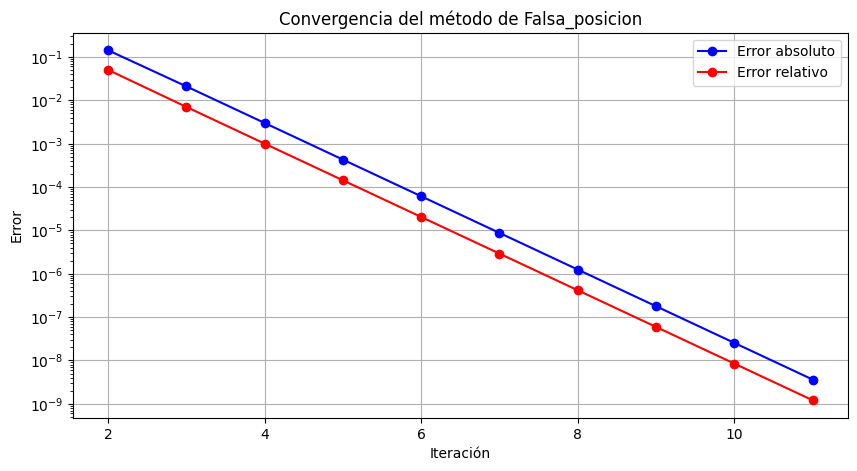


Tabla de iteraciones para método de Falsa_posicion:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 4.000000 | 6.000000 | 4.900000 | -0.990000 |      nan        |            nan        |
|    2.000000 | 4.900000 | 6.000000 | 4.990826 | -0.091659 |        0.090826 |              0.018536 |
|    3.000000 | 4.990826 | 6.000000 | 4.999165 | -0.008347 |        0.008340 |              0.001671 |
|    4.000000 | 4.999165 | 6.000000 | 4.999924 | -0.000759 |        0.000759 |              0.000152 |
|    5.000000 | 4.999924 | 6.000000 | 4.999993 | -0.000069 |        0.000069 |              0.000014 |
|    6.000000 | 4.999993 | 6.000000 | 4.999999 | -0.000006 |        0.000006 |              0.000001 |
|    7.000000 | 4.999999 | 6.000000 | 5.000000 | -0.000001 |        0.000001 |              0.000000 |
|    8.000000 | 5.00

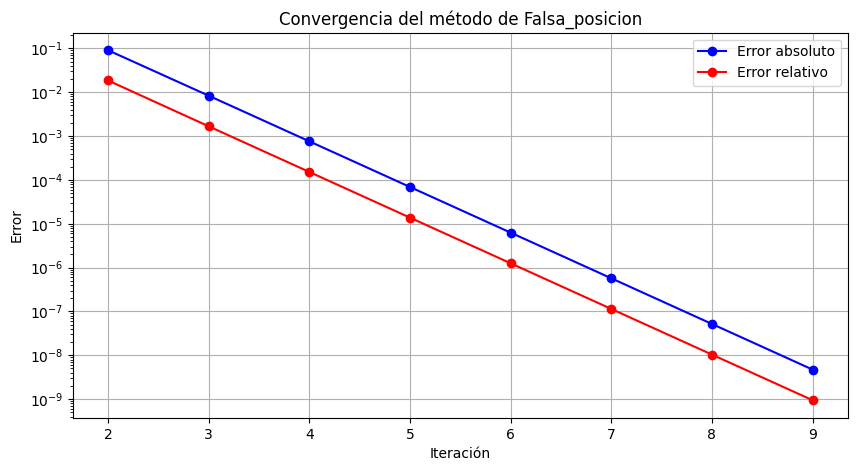

In [ ]:
resultado, historico, info = raiz_cuadrada(4, (1, 3), metodo='falsa_posicion')
resultado, historico, info = raiz_cuadrada(9, (2, 4), metodo='falsa_posicion')
resultado, historico, info = raiz_cuadrada(25, (4, 6), metodo='falsa_posicion')

Este método combina la seguridad de la bisección (siempre converge) con mayor velocidad al usar interpolación lineal. Sin embargo, puede volverse lento si un extremo del intervalo se estanca. Es confiable para raíces bien aisladas, pero en algunos casos converge más lentamente que la secante. Ideal cuando se busca un equilibrio entre robustez y eficiencia en funciones continuas.

### Método de falsa posición modificado (Illinois)
 Prueba para los casos conocidos: $\sqrt{4}$, $\sqrt{9}$, $\sqrt{16}$ (con diferentes intervalos iniciales), $\sqrt{25}$, $\sqrt{100}$



Tabla de iteraciones para método de Illinois:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 3.000000 | 5.000000 | 3.875000 | -0.984375 |      nan        |            nan        |
|    2.000000 | 3.875000 | 5.000000 | 3.985915 | -0.112478 |        0.110915 |              0.028623 |
|    3.000000 | 3.985915 | 5.000000 | 4.010644 |  0.085269 |        0.024729 |              0.006204 |
|    4.000000 | 3.985915 | 4.010644 | 3.999981 | -0.000150 |        0.010663 |              0.002659 |
|    5.000000 | 3.999981 | 4.010644 | 4.000000 | -0.000000 |        0.000019 |              0.000005 |
|    6.000000 | 4.000000 | 4.010644 | 4.000000 |  0.000000 |        0.000000 |              0.000000 |
|    7.000000 | 4.000000 | 4.000000 | 4.000000 |  0.000000 |        0.000000 |              0.000000 |


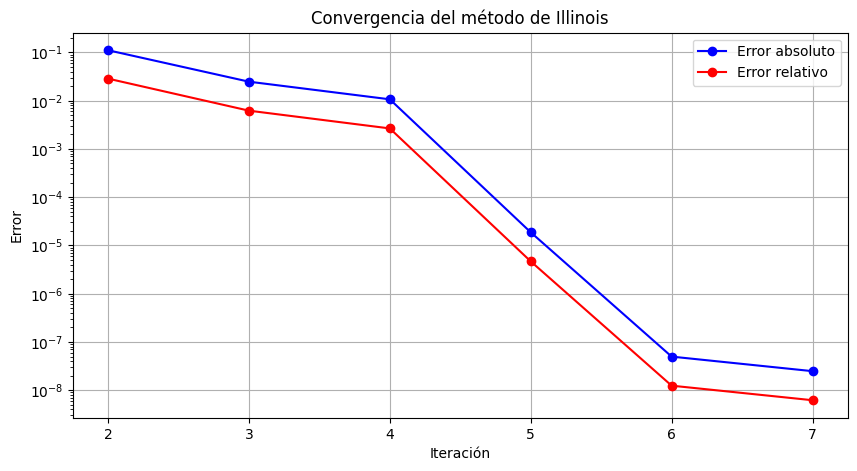


Tabla de iteraciones para método de Illinois:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 1.000000 | 5.000000 | 3.500000 | -3.750000 |      nan        |            nan        |
|    2.000000 | 3.500000 | 5.000000 | 3.941176 | -0.467128 |        0.441176 |              0.126050 |
|    3.000000 | 3.941176 | 5.000000 | 4.040752 |  0.327680 |        0.099576 |              0.025266 |
|    4.000000 | 3.941176 | 4.040752 | 3.999700 | -0.002403 |        0.041053 |              0.010160 |
|    5.000000 | 3.999700 | 4.040752 | 3.999998 | -0.000012 |        0.000299 |              0.000075 |
|    6.000000 | 3.999998 | 4.040752 | 4.000002 |  0.000012 |        0.000003 |              0.000001 |
|    7.000000 | 3.999998 | 4.000002 | 4.000000 | -0.000000 |        0.000002 |              0.000000 |


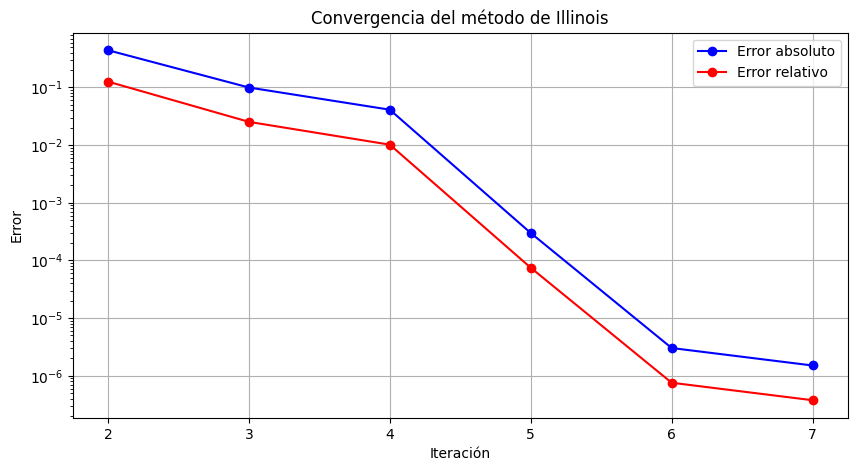


Tabla de iteraciones para método de Illinois:
|   Iteración |      a_n |       b_n |      c_n |     f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|----------:|---------:|-----------:|----------------:|----------------------:|
|    1.000000 | 0.000000 | 10.000000 | 1.600000 | -13.440000 |      nan        |            nan        |
|    2.000000 | 1.600000 | 10.000000 | 2.758621 |  -8.390012 |        1.158621 |              0.724138 |
|    3.000000 | 2.758621 | 10.000000 | 3.964321 |  -0.284158 |        1.205700 |              0.437066 |
|    4.000000 | 3.964321 | 10.000000 | 4.044902 |   0.361229 |        0.080580 |              0.020326 |
|    5.000000 | 3.964321 |  4.044902 | 3.999800 |  -0.001600 |        0.045102 |              0.011150 |
|    6.000000 | 3.999800 |  4.044902 | 3.999999 |  -0.000009 |        0.000199 |              0.000050 |
|    7.000000 | 3.999999 |  4.044902 | 4.000001 |   0.000009 |        0.000002 |              0.000001 |
|    8.0

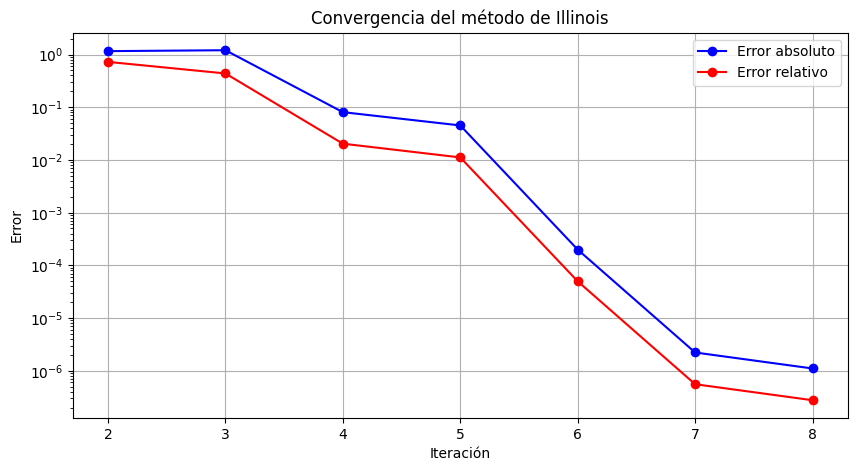

In [ ]:
resultado, historico, info = raiz_cuadrada(16, (3, 5), metodo='illinois')
resultado, historico, info = raiz_cuadrada(16, (1, 5), metodo='illinois')
resultado, historico, info = raiz_cuadrada(16, (0, 10), metodo='illinois')


Tabla de iteraciones para método de Illinois:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 1.000000 | 3.000000 | 1.750000 | -0.937500 |      nan        |            nan        |
|    2.000000 | 1.750000 | 3.000000 | 1.947368 | -0.207756 |        0.197368 |              0.112782 |
|    3.000000 | 1.947368 | 3.000000 | 2.028133 |  0.113323 |        0.080765 |              0.041474 |
|    4.000000 | 1.947368 | 2.028133 | 1.999628 | -0.001490 |        0.028505 |              0.014055 |
|    5.000000 | 1.999628 | 2.028133 | 1.999997 | -0.000010 |        0.000370 |              0.000185 |
|    6.000000 | 1.999997 | 2.028133 | 2.000003 |  0.000010 |        0.000005 |              0.000003 |
|    7.000000 | 1.999997 | 2.000003 | 2.000000 | -0.000000 |        0.000003 |              0.000001 |


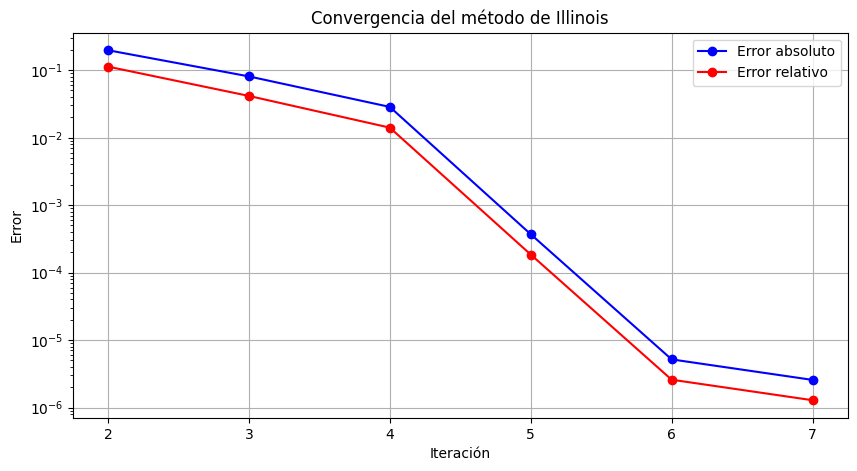


Tabla de iteraciones para método de Illinois:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 2.000000 | 4.000000 | 2.833333 | -0.972222 |      nan        |            nan        |
|    2.000000 | 2.833333 | 4.000000 | 2.975610 | -0.145747 |        0.142276 |              0.050215 |
|    3.000000 | 2.975610 | 4.000000 | 3.016562 |  0.099646 |        0.040952 |              0.013763 |
|    4.000000 | 2.975610 | 3.016562 | 2.999933 | -0.000404 |        0.016629 |              0.005513 |
|    5.000000 | 2.999933 | 3.016562 | 3.000000 | -0.000001 |        0.000067 |              0.000022 |
|    6.000000 | 3.000000 | 3.016562 | 3.000000 |  0.000001 |        0.000000 |              0.000000 |
|    7.000000 | 3.000000 | 3.000000 | 3.000000 | -0.000000 |        0.000000 |              0.000000 |


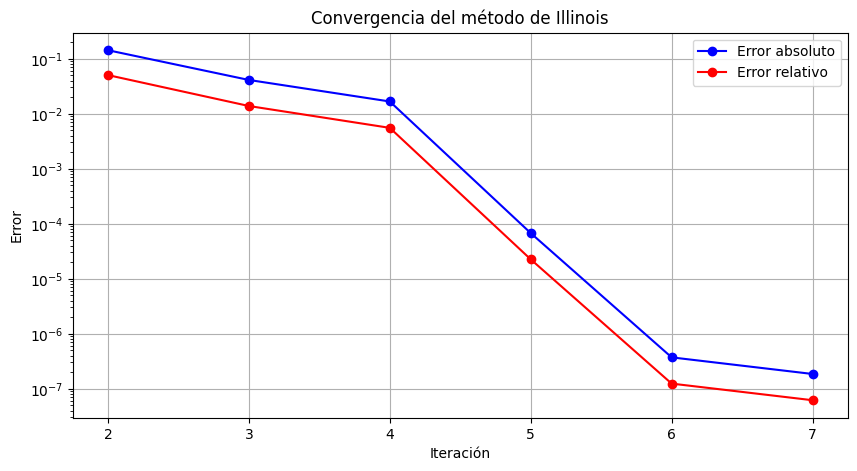


Tabla de iteraciones para método de Illinois:
|   Iteración |      a_n |      b_n |      c_n |    f(c_n) |   |c_{n+1}-c_n| |   |(c_{n+1}-c_n)/c_n| |
|------------:|---------:|---------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 4.000000 | 6.000000 | 4.900000 | -0.990000 |      nan        |            nan        |
|    2.000000 | 4.900000 | 6.000000 | 4.990826 | -0.091659 |        0.090826 |              0.018536 |
|    3.000000 | 4.990826 | 6.000000 | 5.007368 |  0.073736 |        0.016542 |              0.003315 |
|    4.000000 | 4.990826 | 5.007368 | 4.999993 | -0.000068 |        0.007375 |              0.001473 |
|    5.000000 | 4.999993 | 5.007368 | 5.000000 | -0.000000 |        0.000007 |              0.000001 |
|    6.000000 | 5.000000 | 5.007368 | 5.000000 |  0.000000 |        0.000000 |              0.000000 |


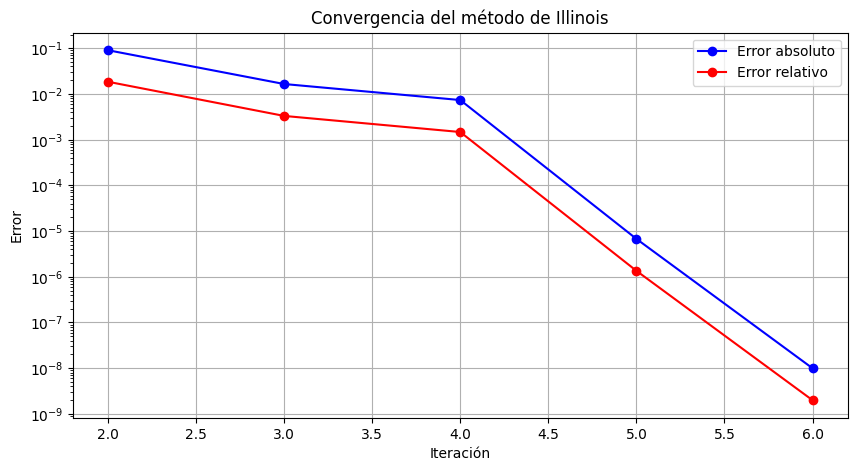

In [ ]:
resultado, historico, info = raiz_cuadrada(4, (1, 3), metodo='illinois')
resultado, historico, info = raiz_cuadrada(9, (2, 4), metodo='illinois')
resultado, historico, info = raiz_cuadrada(25, (4, 6), metodo='illinois')



### Conclusiones

Este método mejora la falsa posición al corregir su principal debilidad: la convergencia lenta por extremos estancados. Al reducir sistemáticamente el valor de la función en el punto fijo, acelera la convergencia manteniendo la garantía de encontrar la raíz. Es más eficiente que la falsa posición tradicional, especialmente en funciones con comportamientos asimétricos cerca de la raíz, aunque sigue siendo menos rápido que métodos como Newton o la secante en casos ideales.

### Método de Newton-Raphson

Prueba para los casos conocidos: $\sqrt{4}$, $\sqrt{9}$, $\sqrt{16}$ (como diferentes valores iniciales), $\sqrt{25}$, $\sqrt{100}$


Tabla de iteraciones para método de Newton:
|   Iteración |      x_n |    f(x_n) |   |x_{n+1}-x_n| |   |(x_{n+1}-x_n)/x_n| |
|------------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 8.500000 | 56.250000 |      nan        |            nan        |
|    2.000000 | 5.191176 | 10.948313 |        3.308824 |              0.389273 |
|    3.000000 | 4.136665 |  1.111995 |        1.054512 |              0.203135 |
|    4.000000 | 4.002258 |  0.018065 |        0.134407 |              0.032492 |
|    5.000000 | 4.000001 |  0.000005 |        0.002257 |              0.000564 |
|    6.000000 | 4.000000 |  0.000000 |        0.000001 |              0.000000 |


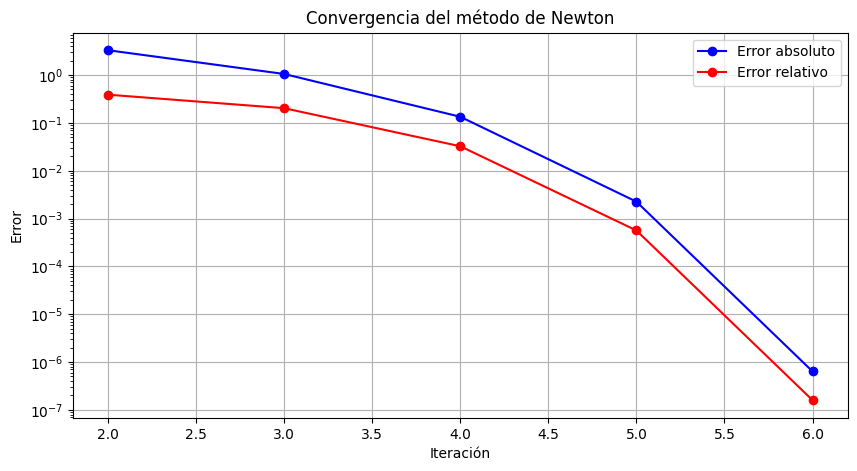


Tabla de iteraciones para método de Newton:
|   Iteración |      x_n |   f(x_n) |   |x_{n+1}-x_n| |   |(x_{n+1}-x_n)/x_n| |
|------------:|---------:|---------:|----------------:|----------------------:|
|    1.000000 | 4.000000 | 0.000000 |      nan        |            nan        |
|    2.000000 | 4.000000 | 0.000000 |        0.000000 |              0.000000 |


<ipython-input-2-e57e8271edc0>:111: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


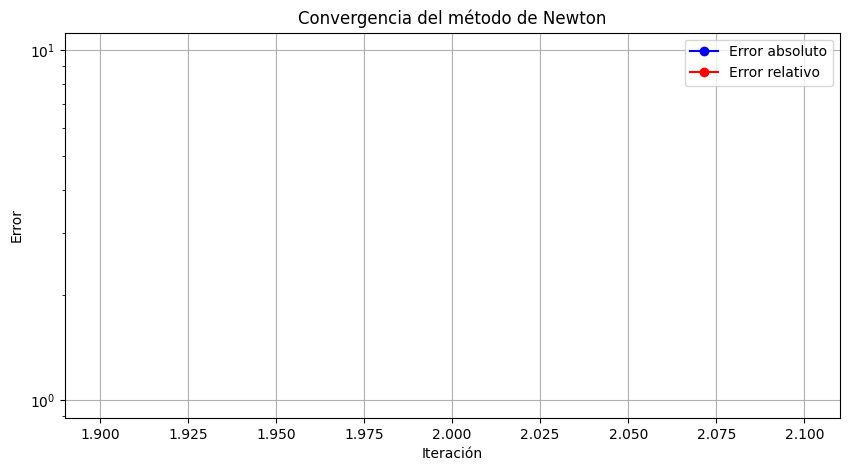


Tabla de iteraciones para método de Newton:
|   Iteración |      x_n |    f(x_n) |   |x_{n+1}-x_n| |   |(x_{n+1}-x_n)/x_n| |
|------------:|---------:|----------:|----------------:|----------------------:|
|    1.000000 | 5.800000 | 17.640000 |      nan        |            nan        |
|    2.000000 | 4.279310 |  2.312497 |        1.520690 |              0.262188 |
|    3.000000 | 4.009115 |  0.073005 |        0.270195 |              0.063140 |
|    4.000000 | 4.000010 |  0.000083 |        0.009105 |              0.002271 |
|    5.000000 | 4.000000 |  0.000000 |        0.000010 |              0.000003 |


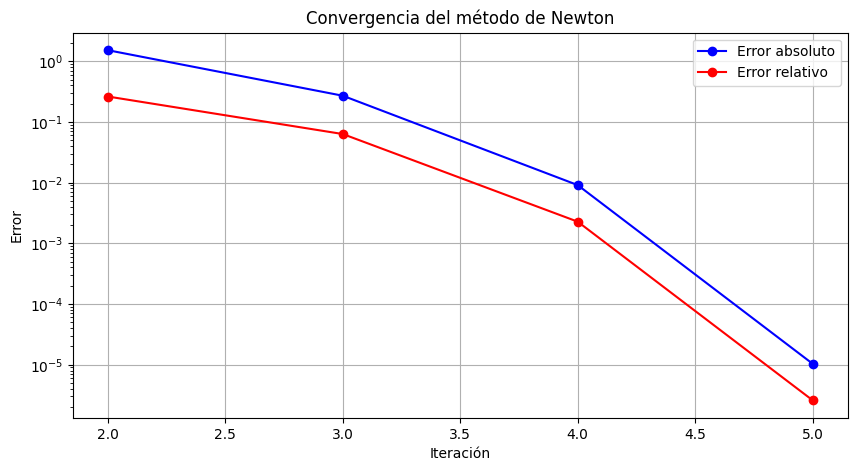


Tabla de iteraciones para método de Newton:
|   Iteración |       x_n |      f(x_n) |   |x_{n+1}-x_n| |   |(x_{n+1}-x_n)/x_n| |
|------------:|----------:|------------:|----------------:|----------------------:|
|    1.000000 | 50.080000 | 2492.006400 |      nan        |            nan        |
|    2.000000 | 25.199744 |  619.027118 |       24.880256 |              0.496810 |
|    3.000000 | 12.917336 |  150.857563 |       12.282409 |              0.487402 |
|    4.000000 |  7.077991 |   34.097951 |        5.839345 |              0.452055 |
|    5.000000 |  4.669260 |    5.801985 |        2.408731 |              0.340313 |
|    6.000000 |  4.047964 |    0.386009 |        0.621296 |              0.133061 |
|    7.000000 |  4.000284 |    0.002273 |        0.047679 |              0.011779 |
|    8.000000 |  4.000000 |    0.000000 |        0.000284 |              0.000071 |
|    9.000000 |  4.000000 |    0.000000 |        0.000000 |              0.000000 |


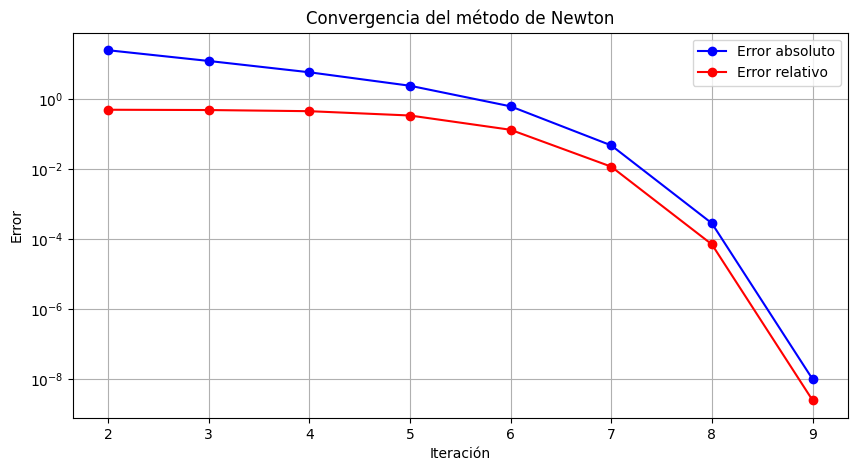

In [ ]:
resultado, historico, info = raiz_cuadrada(16, 1, metodo='newton')
resultado, historico, info = raiz_cuadrada(16, 4, metodo='newton')
resultado, historico, info = raiz_cuadrada(16, 10, metodo='newton')
resultado, historico, info = raiz_cuadrada(16, 100, metodo='newton')


Tabla de iteraciones para método de Newton:
|   Iteración |        x_n |      f(x_n) |   |x_{n+1}-x_n| |   |(x_{n+1}-x_n)/x_n| |
|------------:|-----------:|------------:|----------------:|----------------------:|
|    1.000000 | 100.010000 | 9998.000100 |      nan        |            nan        |
|    2.000000 |  50.024998 | 2498.500425 |       49.985002 |              0.499800 |
|    3.000000 |  25.052479 |  623.626705 |       24.972519 |              0.499201 |
|    4.000000 |  12.606072 |  154.913049 |       12.446407 |              0.496813 |
|    5.000000 |   6.461690 |   37.753433 |        6.144382 |              0.487415 |
|    6.000000 |   3.540361 |    8.534159 |        2.921328 |              0.452100 |
|    7.000000 |   2.335095 |    1.452668 |        1.205267 |              0.340436 |
|    8.000000 |   2.024044 |    0.096753 |        0.311051 |              0.133207 |
|    9.000000 |   2.000143 |    0.000571 |        0.023901 |              0.011808 |
|   10.000000 |   2.

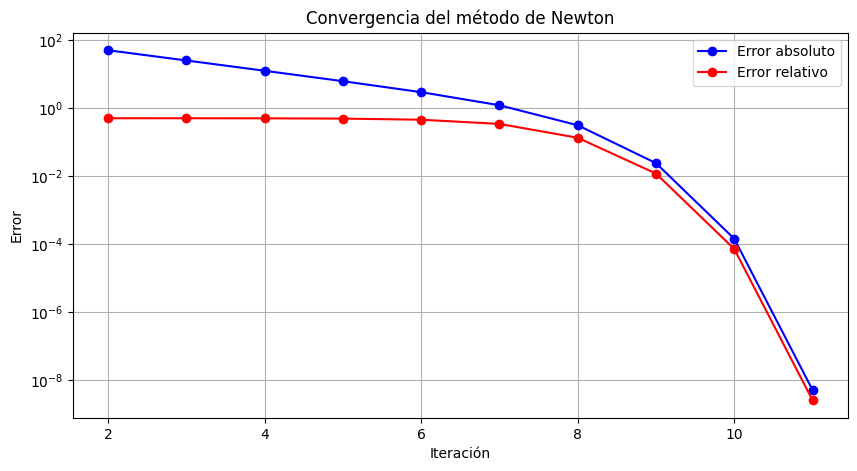


Tabla de iteraciones para método de Newton:
|   Iteración |      x_n |   f(x_n) |   |x_{n+1}-x_n| |   |(x_{n+1}-x_n)/x_n| |
|------------:|---------:|---------:|----------------:|----------------------:|
|    1.000000 | 3.250000 | 1.562500 |      nan        |            nan        |
|    2.000000 | 3.009615 | 0.057785 |        0.240385 |              0.073964 |
|    3.000000 | 3.000015 | 0.000092 |        0.009600 |              0.003190 |
|    4.000000 | 3.000000 | 0.000000 |        0.000015 |              0.000005 |


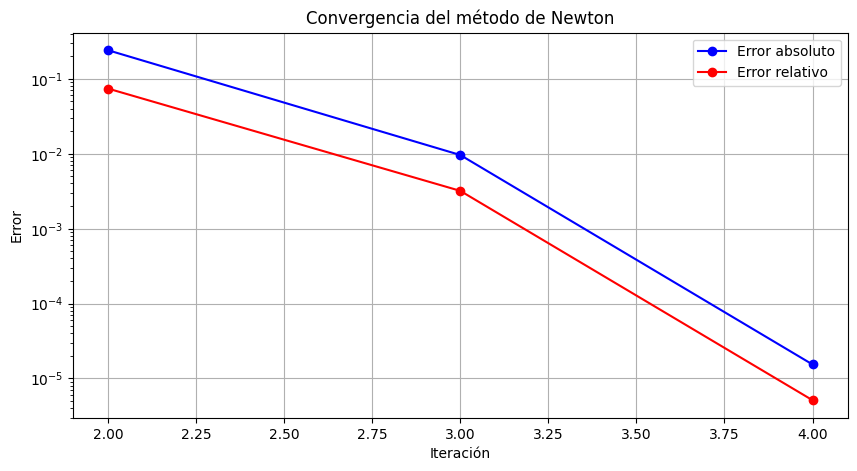


Tabla de iteraciones para método de Newton:
|   Iteración |       x_n |     f(x_n) |   |x_{n+1}-x_n| |   |(x_{n+1}-x_n)/x_n| |
|------------:|----------:|-----------:|----------------:|----------------------:|
|    1.000000 | 13.000000 | 144.000000 |      nan        |            nan        |
|    2.000000 |  7.461538 |  30.674556 |        5.538462 |              0.426036 |
|    3.000000 |  5.406027 |   4.225128 |        2.055511 |              0.275481 |
|    4.000000 |  5.015248 |   0.152709 |        0.390779 |              0.072286 |
|    5.000000 |  5.000023 |   0.000232 |        0.015224 |              0.003036 |
|    6.000000 |  5.000000 |   0.000000 |        0.000023 |              0.000005 |


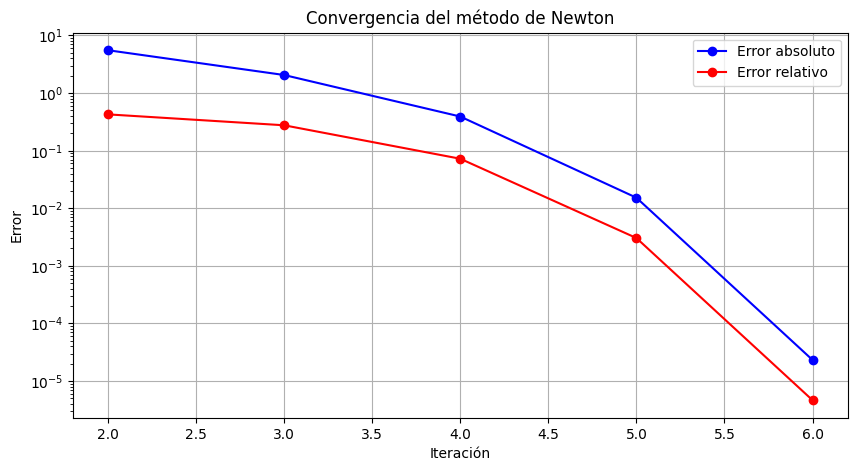

In [ ]:
resultado, historico, info = raiz_cuadrada(4, 200, metodo='newton')
resultado, historico, info = raiz_cuadrada(9, 2, metodo='newton')
resultado, historico, info = raiz_cuadrada(25, 25, metodo='newton')

Ofrece convergencia rápida (cuadrática) como se puede ver en la grafica del error por la forma en loa que este disminuye, pero puede fallar si la derivada es cero o el punto inicial está mal elegido. Requiere calcular derivadas y no siempre converge. Es eficiente en casos ideales, pero menos robusto que métodos como bisección.

# Conclusiones Finales


| Método         | Convergencia       | Requiere derivada? | Robustez | Velocidad     |
|----------------|--------------------|--------------------|----------|---------------|
| **Bisección**  | Lineal (p=1)       | No                 | Alta     | Lenta         |
| **Falsa Posición** | Lineal (p=1)    | No                 | Alta     | Media         |
| **Illinois**   | Superlineal (p>1)  | No                 | Alta     | Media-Rápida  |
| **Secante**    | Superlineal (p≈1.618) | No            | Media    | Rápida        |
| **Newton-Raphson** | Cuadrática (p=2) | Sí             | Baja     | Muy Rápida    |



# Bibliografía

 *   Richard L. Burden, Douglas J. Faires & Annette M. Burden, Análisis numérico, 10a ed, CENGAGE Learning (2016).

*   Invitación al Análisis Numérico, Carlos Enrique Mejía Salazar,
 Universidad Nacional de Colombia,
 Escuela de Matemáticas (2002).





